# Ejercicio 5: Espacio Vectorial

## Objetivo de la práctica
- Implementar un Sistema de Recuperación de Información completo, desde la lectura del corpus hasta la recuperación de resultados.

## Parte 0: Carga del Corpus

Vamos a utilizar la API de Kaggle para acceder al dataset _Wikipedia Text Corpus for NLP and LLM Projects_

El corpus está disponible desde este [link](https://www.kaggle.com/datasets/gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects?utm_source=chatgpt.com)

### Actividad

1. Carga el corpus
2. Realiza las etapas de preprocesamiento sobre el corpus


In [2]:
import re
import numpy as np
import pandas as pd

# 1. Carga del corpus Wikipedia Text Corpus for NLP and LLM Projects
df = pd.read_csv('wikipedia_text_corpus.csv')
corpus = df['text'].dropna().tolist()
doc_names = [doc.split('\n')[0][:80] for doc in corpus]
print(f"Artículos cargados: {len(corpus)}")

# 2. Preprocesamiento: minúsculas + eliminar caracteres no alfanuméricos
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

corpus_processed = [preprocess(doc) for doc in corpus]
print(f"Ejemplo procesado:\n{corpus_processed[0][:200]}")


Artículos cargados: 10859
Ejemplo procesado:
anovo anovo formerly a novo is a computer services company based in beauvais france it was founded in 1987 went public in 1999 and is currently a member of the cac small it won in the category service


## Parte 1: Recuperación con TF-IDF

### Actividad:
3. Obtén la representación vectorial de los documentos utilizando el modelo TF-IDF
4. A partir de un conjunto de 10 queries, verifica la recuperación del sistema

In [3]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Matriz TF y TF-IDF
count_vec = CountVectorizer(stop_words='english', min_df=5, max_df=0.95)
tf_matrix = count_vec.fit_transform(corpus_processed)

tfidf_transformer = TfidfTransformer()
tfidf_matrix = tfidf_transformer.fit_transform(tf_matrix)

vocab = count_vec.get_feature_names_out()
print(f"Matriz TF-IDF: {tfidf_matrix.shape}  (docs × términos)")

# 2. Representación vectorial — muestra de 100 docs × top 10 términos
df_values = np.asarray((tf_matrix > 0).sum(axis=0)).flatten()
top10_idx = df_values.argsort()[::-1][:10]

print(f"\nTop 10 términos más frecuentes (DF):")
for i in top10_idx:
    print(f"  {vocab[i]}: {df_values[i]} docs")

sample = pd.DataFrame(
    tfidf_matrix[:100, top10_idx].toarray(),
    columns=vocab[top10_idx]
)
print(f"\nMuestra TF-IDF (100 docs × top 10 términos):")
print(sample)

Matriz TF-IDF: (10859, 32930)  (docs × términos)

Top 10 términos más frecuentes (DF):
  used: 6285 docs
  use: 4804 docs
  time: 3957 docs
  based: 3889 docs
  using: 3851 docs
  new: 3797 docs
  high: 3475 docs
  including: 3369 docs
  technology: 3260 docs
  known: 3229 docs

Muestra TF-IDF (100 docs × top 10 términos):
        used       use      time     based     using       new      high  \
0   0.000000  0.000000  0.000000  0.072938  0.000000  0.000000  0.000000   
1   0.053645  0.020988  0.011615  0.000000  0.011772  0.000000  0.000000   
2   0.000000  0.000000  0.016379  0.016520  0.016600  0.000000  0.017438   
3   0.045068  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
4   0.037991  0.022295  0.000000  0.000000  0.000000  0.000000  0.026271   
..       ...       ...       ...       ...       ...       ...       ...   
95  0.000000  0.000000  0.035513  0.000000  0.000000  0.036242  0.000000   
96  0.000000  0.036112  0.039969  0.000000  0.000000  0.000000  0.0

In [4]:
# 3. Función de búsqueda con TF-IDF
def buscar_tfidf(query, top_n=10):
    query_tf    = count_vec.transform([query])
    query_tfidf = tfidf_transformer.transform(query_tf)
    scores      = cosine_similarity(query_tfidf, tfidf_matrix).flatten()
    ranking_idx = scores.argsort()[::-1][:top_n]
    return pd.DataFrame({
        'Ranking'  : range(1, top_n + 1),
        'Documento': [doc_names[i] for i in ranking_idx],
        'Score'    : [scores[i] for i in ranking_idx]
    })

# 4. Verificar con 10 queries
queries = [
    "Chemical Agent Resistant Coating",
    "computer programming software",
    "cars automotive industry",
    "music instruments genres",
    "biology evolution",
    "mathematics algebra equations",
    "space planets solar system",
    "Ecuador South America",
    "economics global markets",
    "Scoccer football players",
]

for q in queries:
    print(f"\nQuery: '{q}'")
    print(buscar_tfidf(q).to_string(index=False))


Query: 'Chemical Agent Resistant Coating'
 Ranking                                  Documento    Score
       1                           Hot melt coating 0.325545
       2           Chemical Agent Resistant Coating 0.312883
       3                          Chemical engineer 0.278768
       4                           Chemical process 0.277258
       5                    Open Agent Architecture 0.239064
       6 Foundation for Intelligent Physical Agents 0.229229
       7                      Chemical technologist 0.226317
       8            Laser chemical vapor deposition 0.193316
       9                          Chemical industry 0.191741
      10                         Conversion coating 0.187839

Query: 'computer programming software'
 Ranking                 Documento    Score
       1                  Software 0.569488
       2        System programming 0.561677
       3                 Computing 0.539631
       4 Psychology of programming 0.530468
       5      Software dev

## Parte 2: Recuperación con BM25

### Actividad:
5. Implementa un sistema de recuperación usando el modelo BM25.
6. Para el mismo conjunto de 10 queries, verifica la recuperación del sistema

In [10]:
from rank_bm25 import BM25Okapi

# Convertir el corpus a una lista de listas de términos
corpus = [doc.split() for doc in doc_names]

# Inicializar el modelo BM25
bm25 = BM25Okapi(corpus)

# Función de ranking BM25
def bm25_ranking(query, top_n=5):
    query_terms = query.split()
    scores = bm25.get_scores(query_terms)
    ranking_idx = scores.argsort()[::-1][:top_n]
    return pd.DataFrame({
        'Ranking'   : range(1, top_n + 1),
        'Documento' : [doc_names[i] for i in ranking_idx],
        'Score BM25': [scores[i] for i in ranking_idx]
    })

# Verificar con las mismas 10 queries
for q in queries:
    print(f"\nQuery: '{q}'")
    print(bm25_ranking(q).to_string(index=False))



Query: 'Chemical Agent Resistant Coating'
 Ranking                        Documento  Score BM25
       1 Chemical Agent Resistant Coating   25.586746
       2          Open Agent Architecture    7.642320
       3                Chemical computer    7.166698
       4                Chemical engineer    7.166698
       5                 Chemical process    7.166698

Query: 'computer programming software'
 Ranking                   Documento  Score BM25
       1          System programming    7.593299
       2  Emission-aware programming    7.593299
       3 Example-centric programming    7.593299
       4  Immunity-aware programming    7.593299
       5              IC programming    7.593299

Query: 'cars automotive industry'
 Ranking             Documento  Score BM25
       1 Cable cars in Chicago    6.953700
       2     Chemical industry    6.860312
       3      Housing industry    6.860312
       4     Cultural industry    6.860312
       5         Meat industry    6.860312

Query

## Parte 3: Comparación de resultados

### Actividad:
7. Verifica cuáles documentos son recuperados (y en qué orden) por cada modelo de recuperación 

Query: 'Chemical Agent Resistant Coating'

TF-IDF:
 Ranking                                  Documento    Score
       1                           Hot melt coating 0.325545
       2           Chemical Agent Resistant Coating 0.312883
       3                          Chemical engineer 0.278768
       4                           Chemical process 0.277258
       5                    Open Agent Architecture 0.239064
       6 Foundation for Intelligent Physical Agents 0.229229
       7                      Chemical technologist 0.226317
       8            Laser chemical vapor deposition 0.193316
       9                          Chemical industry 0.191741
      10                         Conversion coating 0.187839

BM25:
 Ranking                        Documento  Score BM25
       1 Chemical Agent Resistant Coating   25.586746
       2          Open Agent Architecture    7.642320
       3                Chemical computer    7.166698
       4                Chemical engineer    7.166698
 

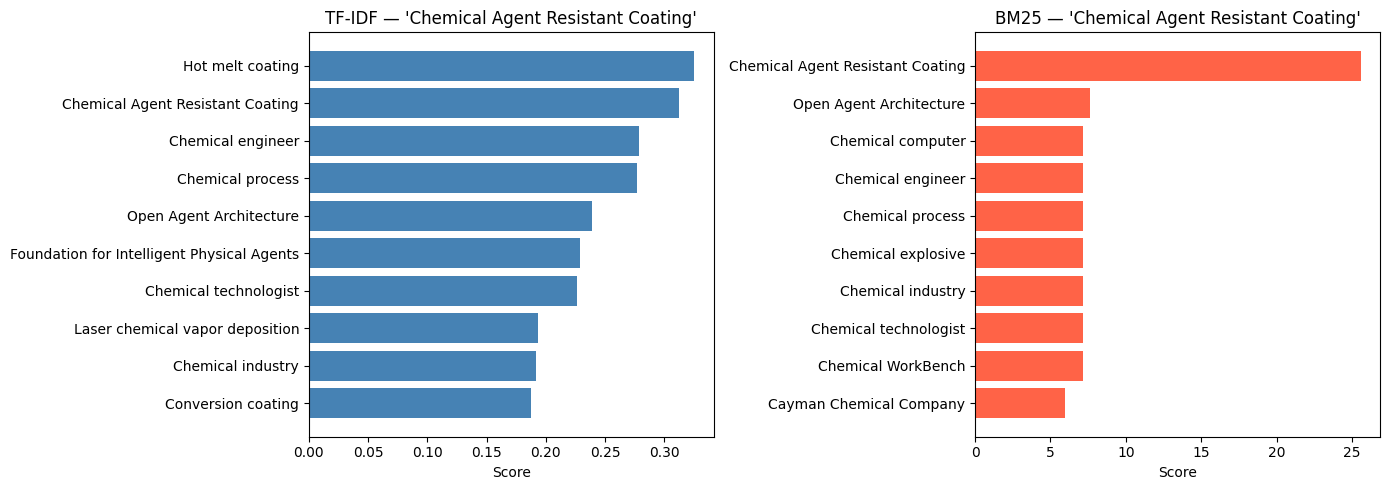

In [ ]:
import matplotlib.pyplot as plt

# Elegir una query para comparar
query = queries[0]

# Obtener top 10 de cada modelo
resultado_tfidf = buscar_tfidf(query, top_n=10)
resultado_bm25  = bm25_ranking(query, top_n=10)

print(f"Query: '{query}'")
print("\nTF-IDF:")
print(resultado_tfidf.to_string(index=False))
print("\nBM25:")
print(resultado_bm25.to_string(index=False))

# Documentos en común
comunes = set(resultado_tfidf['Documento']) & set(resultado_bm25['Documento'])
print(f"\nDocumentos en común: {len(comunes)}/10 -> {comunes}")

# Gráfico comparativo
docs_tfidf = resultado_tfidf['Documento'].tolist()
docs_bm25  = resultado_bm25['Documento'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(docs_tfidf[::-1], resultado_tfidf['Score'][::-1], color='steelblue')
axes[0].set_title(f"TF-IDF — '{query}'")
axes[0].set_xlabel('Score')

axes[1].barh(docs_bm25[::-1], resultado_bm25['Score BM25'][::-1], color='tomato')
axes[1].set_title(f"BM25 — '{query}'")
axes[1].set_xlabel('Score')

plt.tight_layout()
plt.show()
